<h2><strong>Import Libraries</strong></h2>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import r2_score

In [2]:
# Change Pandas Display Options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)  

<h2><strong>Read & Verify CSVs</strong></h2>

In [3]:
mortality_df = pd.read_csv('mortality.csv')
print(mortality_df.head(10))

  Country/Territory Code  Year  Meningitis  Alzheimer's_Disease_and_Other_Dementias  Parkinson's_Disease  Nutritional_Deficiencies  Malaria  Drowning  Interpersonal_Violence  Maternal_Disorders  HIV/AIDS  Drug_Use_Disorders  Tuberculosis  Cardiovascular_Diseases  Lower_Respiratory_Infections  Neonatal_Disorders  Alcohol_Use_Disorders  Self-harm  Exposure_to_Forces_of_Nature  Diarrheal_Diseases  Environmental_Heat_and_Cold_Exposure  Neoplasms  Conflict_and_Terrorism  Diabetes_Mellitus  Chronic_Kidney_Disease  Poisonings  Protein-Energy_Malnutrition  Road_Injuries  Chronic_Respiratory_Diseases  Cirrhosis_and_Other_Chronic_Liver_Diseases  Digestive_Diseases  Fire,_Heat,_and_Hot_Substances  Acute_Hepatitis  Estimated_Male_Deaths  Estimated_Female_Deaths  Total_Deaths
0       Afghanistan  AFG  1990        2159                                     1116                  371                      2087       93      1370                    1538                2655        34                  93   

In [4]:
salary_df = pd.read_csv('salary_data.csv')
print(salary_df.head(10))

          country_name continent_name wage_span  median_salary  average_salary  lowest_salary  highest_salary
0          Afghanistan           Asia   Monthly         853.74         1001.15         252.53         4460.97
1        Aland Islands         Europe   Monthly        3319.24         3858.35         972.52        17124.74
2              Albania         Europe   Monthly         832.84          956.92         241.22         4258.49
3              Algeria         Africa   Monthly        1148.84         1308.81         330.11         5824.18
4       American Samoa        Oceania   Monthly        1390.00         1570.00         400.00         6980.00
5              Andorra         Europe   Monthly        3668.08         4069.77        1120.51        17653.28
6               Angola         Africa   Monthly         284.39          314.39          79.32         1403.96
7  Antigua and Barbuda      Caribbean   Monthly        1548.15         1677.78         422.22         7444.44
8         

<h2><strong>Data Cleaning</strong></h2>

In [5]:
print(mortality_df.shape)
print(salary_df.shape)

(6120, 37)
(221, 7)


In [6]:
mortality_df.rename(columns={"Country/Territory":"country"}, inplace=True)
salary_df.rename(columns={"country_name":"country"}, inplace=True)

mortality_df["country"] = mortality_df["country"].str.strip()
salary_df["country"] = salary_df["country"].str.strip()

In [7]:
print(mortality_df.isnull().sum())

country                                       0
Code                                          0
Year                                          0
Meningitis                                    0
Alzheimer's_Disease_and_Other_Dementias       0
Parkinson's_Disease                           0
Nutritional_Deficiencies                      0
Malaria                                       0
Drowning                                      0
Interpersonal_Violence                        0
Maternal_Disorders                            0
HIV/AIDS                                      0
Drug_Use_Disorders                            0
Tuberculosis                                  0
Cardiovascular_Diseases                       0
Lower_Respiratory_Infections                  0
Neonatal_Disorders                            0
Alcohol_Use_Disorders                         0
Self-harm                                     0
Exposure_to_Forces_of_Nature                  0
Diarrheal_Diseases                      

In [8]:
print(salary_df.isnull().sum())

country           0
continent_name    0
wage_span         0
median_salary     0
average_salary    0
lowest_salary     0
highest_salary    0
dtype: int64


In [9]:
mortality_cols = mortality_df.columns
print(mortality_cols)
print(len(mortality_cols))

Index(['country', 'Code', 'Year', 'Meningitis', 'Alzheimer's_Disease_and_Other_Dementias', 'Parkinson's_Disease', 'Nutritional_Deficiencies', 'Malaria', 'Drowning', 'Interpersonal_Violence', 'Maternal_Disorders', 'HIV/AIDS', 'Drug_Use_Disorders', 'Tuberculosis', 'Cardiovascular_Diseases', 'Lower_Respiratory_Infections', 'Neonatal_Disorders', 'Alcohol_Use_Disorders', 'Self-harm', 'Exposure_to_Forces_of_Nature', 'Diarrheal_Diseases', 'Environmental_Heat_and_Cold_Exposure', 'Neoplasms', 'Conflict_and_Terrorism', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease', 'Poisonings', 'Protein-Energy_Malnutrition', 'Road_Injuries', 'Chronic_Respiratory_Diseases', 'Cirrhosis_and_Other_Chronic_Liver_Diseases', 'Digestive_Diseases', 'Fire,_Heat,_and_Hot_Substances', 'Acute_Hepatitis', 'Estimated_Male_Deaths', 'Estimated_Female_Deaths', 'Total_Deaths'], dtype='object')
37


In [10]:
salary_cols = salary_df.columns
print(salary_cols)
print(len(salary_cols))

Index(['country', 'continent_name', 'wage_span', 'median_salary', 'average_salary', 'lowest_salary', 'highest_salary'], dtype='object')
7


In [11]:
mortality_numeric_cols = mortality_df.select_dtypes(include=np.number).columns
print(mortality_numeric_cols)
print(len(mortality_numeric_cols))

Index(['Year', 'Meningitis', 'Alzheimer's_Disease_and_Other_Dementias', 'Parkinson's_Disease', 'Nutritional_Deficiencies', 'Malaria', 'Drowning', 'Interpersonal_Violence', 'Maternal_Disorders', 'HIV/AIDS', 'Drug_Use_Disorders', 'Tuberculosis', 'Cardiovascular_Diseases', 'Lower_Respiratory_Infections', 'Neonatal_Disorders', 'Alcohol_Use_Disorders', 'Self-harm', 'Exposure_to_Forces_of_Nature', 'Diarrheal_Diseases', 'Environmental_Heat_and_Cold_Exposure', 'Neoplasms', 'Conflict_and_Terrorism', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease', 'Poisonings', 'Protein-Energy_Malnutrition', 'Road_Injuries', 'Chronic_Respiratory_Diseases', 'Cirrhosis_and_Other_Chronic_Liver_Diseases', 'Digestive_Diseases', 'Fire,_Heat,_and_Hot_Substances', 'Acute_Hepatitis', 'Estimated_Male_Deaths', 'Estimated_Female_Deaths', 'Total_Deaths'], dtype='object')
35


In [12]:
salary_numeric_cols = salary_df.select_dtypes(include=np.number).columns
print(salary_numeric_cols)
print(len(salary_numeric_cols))

Index(['median_salary', 'average_salary', 'lowest_salary', 'highest_salary'], dtype='object')
4


In [13]:
print(mortality_df.dtypes)

country                                       object
Code                                          object
Year                                           int64
Meningitis                                     int64
Alzheimer's_Disease_and_Other_Dementias        int64
Parkinson's_Disease                            int64
Nutritional_Deficiencies                       int64
Malaria                                        int64
Drowning                                       int64
Interpersonal_Violence                         int64
Maternal_Disorders                             int64
HIV/AIDS                                       int64
Drug_Use_Disorders                             int64
Tuberculosis                                   int64
Cardiovascular_Diseases                        int64
Lower_Respiratory_Infections                   int64
Neonatal_Disorders                             int64
Alcohol_Use_Disorders                          int64
Self-harm                                     

In [14]:
print(salary_df.dtypes)

country            object
continent_name     object
wage_span          object
median_salary     float64
average_salary    float64
lowest_salary     float64
highest_salary    float64
dtype: object


<h2><strong>Merge Datasets</strong></h2>

In [15]:
df = pd.merge(mortality_df, salary_df, on="country", how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (5640, 43)


,country,Code,Year,Meningitis,Alzheimer's_Disease_and_Other_Dementias,Parkinson's_Disease,Nutritional_Deficiencies,Malaria,Drowning,Interpersonal_Violence,Maternal_Disorders,HIV/AIDS,Drug_Use_Disorders,Tuberculosis,Cardiovascular_Diseases,Lower_Respiratory_Infections,Neonatal_Disorders,Alcohol_Use_Disorders,Self-harm,Exposure_to_Forces_of_Nature,Diarrheal_Diseases,Environmental_Heat_and_Cold_Exposure,Neoplasms,Conflict_and_Terrorism,Diabetes_Mellitus,Chronic_Kidney_Disease,Poisonings,Protein-Energy_Malnutrition,Road_Injuries,Chronic_Respiratory_Diseases,Cirrhosis_and_Other_Chronic_Liver_Diseases,Digestive_Diseases,"Fire,_Heat,_and_Hot_Substances",Acute_Hepatitis,Estimated_Male_Deaths,Estimated_Female_Deaths,Total_Deaths,continent_name,wage_span,median_salary,average_salary,lowest_salary,highest_salary
0,Afghanistan,AFG,1990,2159,1116,371,2087,93,1370,1538,2655,34,93,4661,44899,23741,15612,72,696,0,4235,175,11580,1490,2108,3709,338,2054,4154,5945,2673,5005,323,2985,81384,66586,147971,Asia,Monthly,853.74,1001.15,252.53,4460.97
1,Afghanistan,AFG,1991,2218,1136,374,2153,189,1391,2001,2885,41,102,4743,45492,24504,17128,75,751,1347,4927,113,11796,3370,2120,3724,351,2119,4472,6050,2728,5120,332,3092,86264,70579,156844,Asia,Monthly,853.74,1001.15,252.53,4460.97
2,Afghanistan,AFG,1992,2475,1162,378,2441,239,1514,2299,3315,48,118,4976,46557,27404,20060,80,855,614,6123,38,12218,4344,2153,3776,386,2404,5106,6223,2830,5335,360,3325,93035,76120,169156,Asia,Monthly,853.74,1001.15,252.53,4460.97
3,Afghanistan,AFG,1993,2812,1187,384,2837,108,1687,2589,3671,56,132,5254,47951,31116,22335,85,943,225,8174,41,12634,4096,2195,3862,425,2797,5681,6445,2943,5568,396,3601,100226,82003,182230,Asia,Monthly,853.74,1001.15,252.53,4460.97
4,Afghanistan,AFG,1994,3027,1211,391,3081,211,1809,2849,3863,63,142,5470,49308,33390,23288,88,993,160,8215,44,12914,8959,2231,3932,451,3038,6001,6664,3027,5739,420,3816,107137,87657,194795,Asia,Monthly,853.74,1001.15,252.53,4460.97


In [16]:
meta_cols = [
    "country","Code","Year","continent_name",
    "average_salary","median_salary",
    "lowest_salary","highest_salary",
    "Estimated_Male_Deaths","Estimated_Female_Deaths",
    "Total_Deaths","wage_span"
]

disease_cols = [c for c in df.columns if c not in meta_cols]

df.head()


,country,Code,Year,Meningitis,Alzheimer's_Disease_and_Other_Dementias,Parkinson's_Disease,Nutritional_Deficiencies,Malaria,Drowning,Interpersonal_Violence,Maternal_Disorders,HIV/AIDS,Drug_Use_Disorders,Tuberculosis,Cardiovascular_Diseases,Lower_Respiratory_Infections,Neonatal_Disorders,Alcohol_Use_Disorders,Self-harm,Exposure_to_Forces_of_Nature,Diarrheal_Diseases,Environmental_Heat_and_Cold_Exposure,Neoplasms,Conflict_and_Terrorism,Diabetes_Mellitus,Chronic_Kidney_Disease,Poisonings,Protein-Energy_Malnutrition,Road_Injuries,Chronic_Respiratory_Diseases,Cirrhosis_and_Other_Chronic_Liver_Diseases,Digestive_Diseases,"Fire,_Heat,_and_Hot_Substances",Acute_Hepatitis,Estimated_Male_Deaths,Estimated_Female_Deaths,Total_Deaths,continent_name,wage_span,median_salary,average_salary,lowest_salary,highest_salary
0,Afghanistan,AFG,1990,2159,1116,371,2087,93,1370,1538,2655,34,93,4661,44899,23741,15612,72,696,0,4235,175,11580,1490,2108,3709,338,2054,4154,5945,2673,5005,323,2985,81384,66586,147971,Asia,Monthly,853.74,1001.15,252.53,4460.97
1,Afghanistan,AFG,1991,2218,1136,374,2153,189,1391,2001,2885,41,102,4743,45492,24504,17128,75,751,1347,4927,113,11796,3370,2120,3724,351,2119,4472,6050,2728,5120,332,3092,86264,70579,156844,Asia,Monthly,853.74,1001.15,252.53,4460.97
2,Afghanistan,AFG,1992,2475,1162,378,2441,239,1514,2299,3315,48,118,4976,46557,27404,20060,80,855,614,6123,38,12218,4344,2153,3776,386,2404,5106,6223,2830,5335,360,3325,93035,76120,169156,Asia,Monthly,853.74,1001.15,252.53,4460.97
3,Afghanistan,AFG,1993,2812,1187,384,2837,108,1687,2589,3671,56,132,5254,47951,31116,22335,85,943,225,8174,41,12634,4096,2195,3862,425,2797,5681,6445,2943,5568,396,3601,100226,82003,182230,Asia,Monthly,853.74,1001.15,252.53,4460.97
4,Afghanistan,AFG,1994,3027,1211,391,3081,211,1809,2849,3863,63,142,5470,49308,33390,23288,88,993,160,8215,44,12914,8959,2231,3932,451,3038,6001,6664,3027,5739,420,3816,107137,87657,194795,Asia,Monthly,853.74,1001.15,252.53,4460.97


<h2><strong>Exploratory Data Analysis</strong></h2>

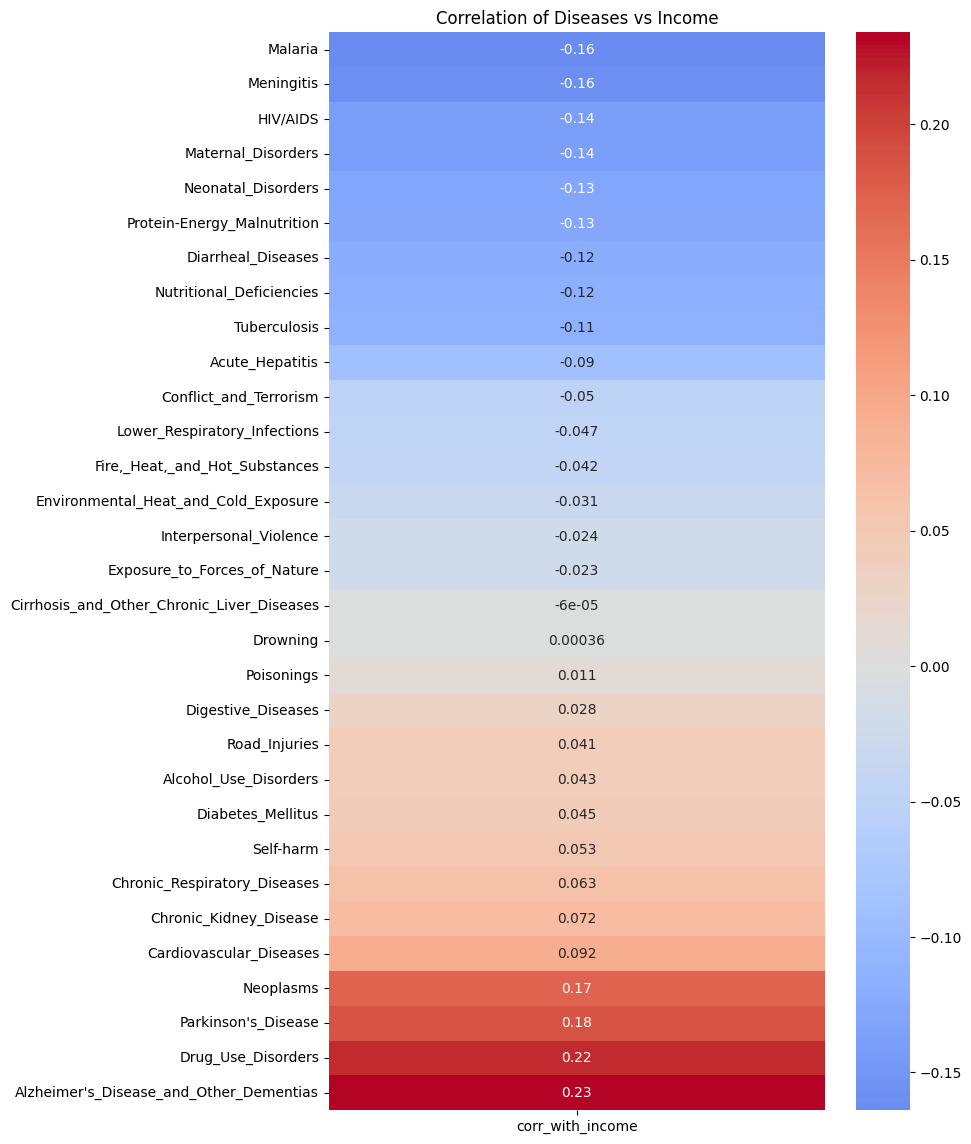

In [17]:
corrs = {}

for disease in disease_cols:
    corrs[disease] = df[disease].corr(df["average_salary"])

corr_df = pd.DataFrame.from_dict(corrs, orient="index", columns=["corr_with_income"])
corr_df = corr_df.sort_values("corr_with_income")

plt.figure(figsize=(8,14))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Diseases vs Income")
plt.show()


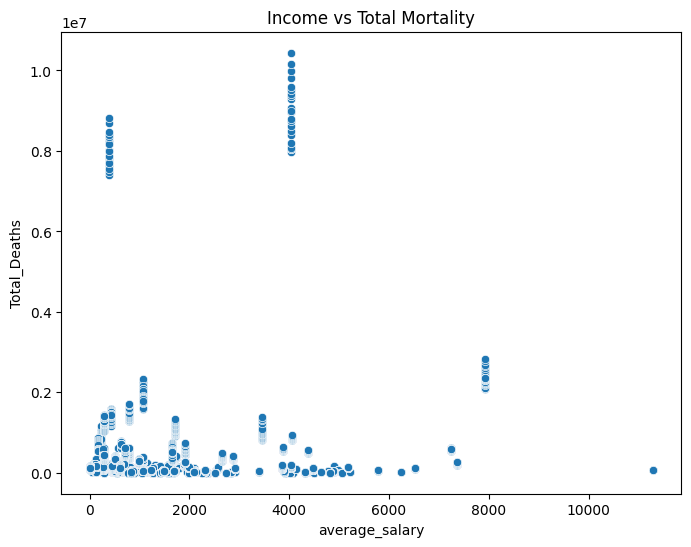

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="average_salary", y="Total_Deaths")
plt.title("Income vs Total Mortality")
plt.show()


                                            corr_with_income
Acute_Hepatitis                                    -0.089515
Conflict_and_Terrorism                             -0.049956
Lower_Respiratory_Infections                       -0.047318
Fire,_Heat,_and_Hot_Substances                     -0.041908
Environmental_Heat_and_Cold_Exposure               -0.030996
Interpersonal_Violence                             -0.023916
Exposure_to_Forces_of_Nature                       -0.022790
Cirrhosis_and_Other_Chronic_Liver_Diseases         -0.000060
Drowning                                            0.000361
Poisonings                                          0.010745
Digestive_Diseases                                  0.028116
Road_Injuries                                       0.041421
Alcohol_Use_Disorders                               0.043003
Diabetes_Mellitus                                   0.044529
Self-harm                                           0.053072
Chronic_Respiratory_Dise

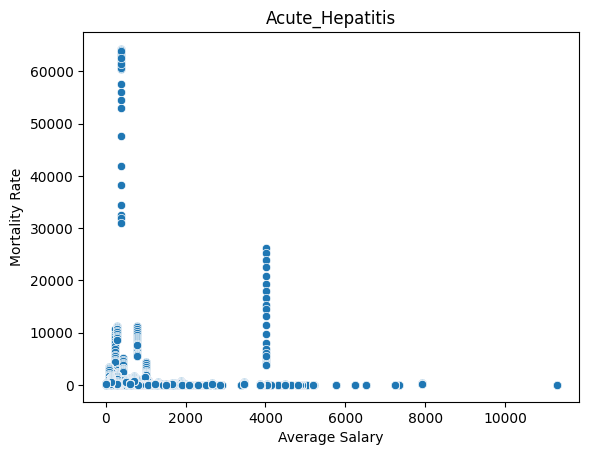

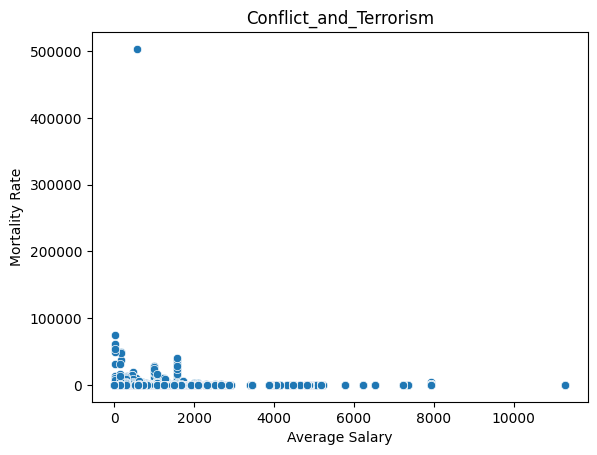

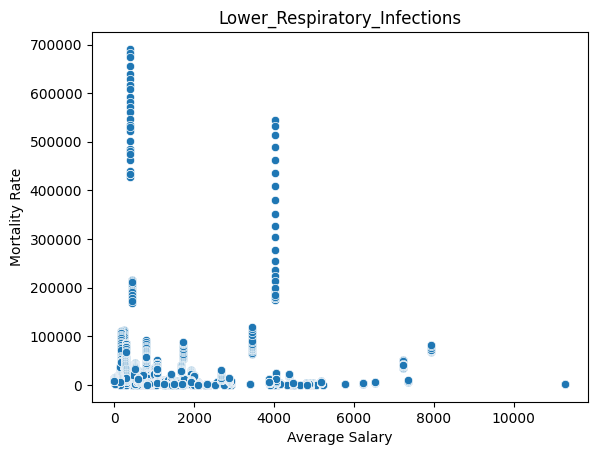

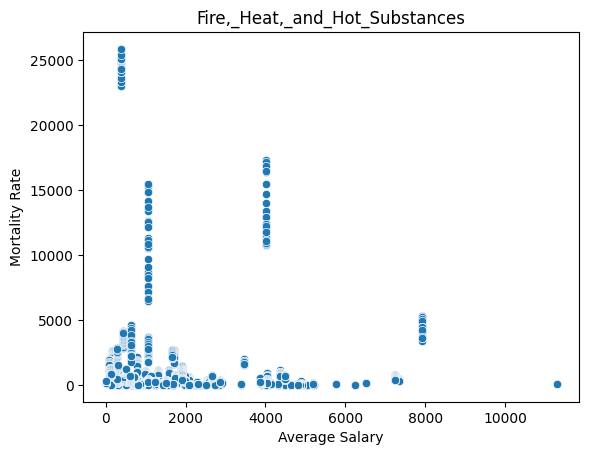

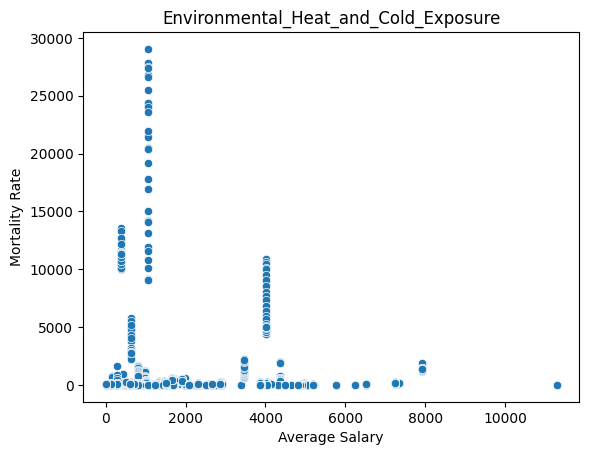

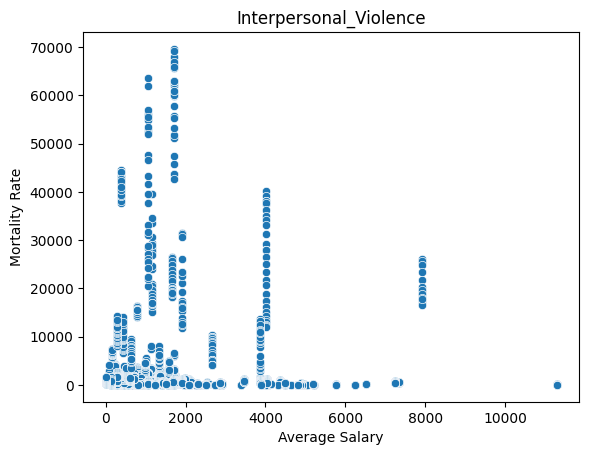

In [19]:
independent = corr_df[abs(corr_df["corr_with_income"]) < 0.1]
print(independent)

top = independent.index[:6]

for disease in top:
    plt.figure()
    sns.scatterplot(x=df["average_salary"], y=df[disease])
    plt.title(disease)
    plt.xlabel("Average Salary")
    plt.ylabel("Mortality Rate")
    plt.show()


<h2><strong>Model Building and Prep</strong></h2>

In [20]:
df["true_total"] = df[disease_cols].sum(axis=1)

df = df[df["true_total"] > 0]

In [21]:
long = df.melt(
    id_vars=["country","Year","average_salary","true_total"],
    value_vars=disease_cols,
    var_name="disease",
    value_name="deaths"
)

long["mortality_share"] = long["deaths"] / long["true_total"]
long["survival_prob"] = 1 - long["mortality_share"]

print(long["survival_prob"].min(), long["survival_prob"].max())

long.head()

0.1643621011265044 1.0


,country,Year,average_salary,true_total,disease,deaths,mortality_share,survival_prob
0,Afghanistan,1990,1001.15,147971,Meningitis,2159,0.014591,0.985409
1,Afghanistan,1991,1001.15,156844,Meningitis,2218,0.014141,0.985859
2,Afghanistan,1992,1001.15,169156,Meningitis,2475,0.014631,0.985369
3,Afghanistan,1993,1001.15,182230,Meningitis,2812,0.015431,0.984569
4,Afghanistan,1994,1001.15,194795,Meningitis,3027,0.015539,0.984461


In [22]:
long = pd.get_dummies(long, columns=["country","disease"])

X = long.drop(columns=["deaths","true_total","mortality_share","survival_prob"])
y = long["survival_prob"]


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)



In [24]:
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
BatchNormalization = tf.keras.layers.BatchNormalization
Model = tf.keras.models.Model
Sequential = tf.keras.Sequential
load_model = tf.keras.models.load_model
Adam = tf.keras.optimizers.Adam

In [25]:
model = Sequential([
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),

    Dense(1, activation="sigmoid")
])


In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    verbose=1
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0066 - mae: 0.0372 - val_loss: 0.0013 - val_mae: 0.0219
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0017 - mae: 0.0213 - val_loss: 9.2643e-04 - val_mae: 0.0156
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0012 - mae: 0.0184 - val_loss: 6.1930e-04 - val_mae: 0.0130
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 9.2239e-04 - mae: 0.0163 - val_loss: 5.3249e-04 - val_mae: 0.0120
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 7.5885e-04 - mae: 0.0147 - val_loss: 4.6643e-04 - val_mae: 0.0107
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 6.4094e-04 - mae: 0.0135 - val_loss: 3.7189e-04 - val_mae: 0.0097
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.6643e-04 - mae: 0.0126 - val_loss: 3.3005e-04 - val_mae: 0.0090
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.0182e-04 - mae: 0.0118 - val_loss: 3.5606e-04 - val_mae: 0.0090


In [27]:
loss, mae = model.evaluate(X_test,y_test)
print("MAE:", mae)

preds = model.predict(X_test)
print("R2:", r2_score(y_test,preds))


1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.3147e-04 - mae: 0.0075
MAE: 0.007523422595113516
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
R2: 0.9547037676925791


In [30]:
def predict_survival(country, disease, income, year):

    sample = pd.DataFrame(columns=X.columns)
    sample.loc[0] = 0

    sample["average_salary"] = income
    sample["Year"] = year

    c = "country_" + country
    d = "disease_" + disease

    if c in sample.columns:
        sample[c] = 1

    if d in sample.columns:
        sample[d] = 1

    sample_scaled = scaler.transform(sample)

    return float(model.predict(sample_scaled, verbose=0)[0][0])



In [37]:
print(predict_survival("Afghanistan","Meningitis",0,2019))
print(predict_survival("Africa","Meningitis",0,2010))

0.9965759515762329
0.9896873831748962
